# AnimalVision-10 CNN Model Development



In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD
import tensorflow as tf

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import shutil


drive_dataset_path = '/content/drive/MyDrive/AnimalVision-10'
colab_dataset_path = 'AnimalVision-10'


if not os.path.exists(drive_dataset_path):
    print(f"Error: Dataset not found in Google Drive at '{drive_dataset_path}'.")
    print("Please ensure you have copied the shared folder to MyDrive/AnimalVision-10.")
else:
    print(f"Copying dataset from '{drive_dataset_path}' to '{colab_dataset_path}'...")
    if os.path.exists(colab_dataset_path):
        shutil.rmtree(colab_dataset_path)
    shutil.copytree(drive_dataset_path, colab_dataset_path)
    print("Dataset copied successfully.")

Copying dataset from '/content/drive/MyDrive/AnimalVision-10' to 'AnimalVision-10'...
Dataset copied successfully.


In [16]:
# Normalize pixel values
if 'X' in locals():
    X = X.astype('float32') / 255.0

    # Convert labels to categorical
    y_cat = to_categorical(y, num_classes=len(class_names))

    # Split dataset: Train (70%), Validation (15%), Test (15%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1))

    print(f"Training set: {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Test set: {X_test.shape}")

Training set: (299, 64, 64, 3)
Validation set: (64, 64, 64, 3)
Test set: (65, 64, 64, 3)


In [ ]:
# Handle Class Imbalance

y_train_indices = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.8542857142857143), 1: np.float64(0.8542857142857143), 2: np.float64(0.8542857142857143), 3: np.float64(5.98), 4: np.float64(1.86875), 5: np.float64(0.8542857142857143), 6: np.float64(0.906060606060606), 7: np.float64(0.8542857142857143), 8: np.float64(0.8542857142857143), 9: np.float64(0.8542857142857143)}


## 2. Data Preprocessing & Augmentation


In [18]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

if 'X_train' in locals():
    datagen.fit(X_train)

## 3. CNN Model Design



In [19]:
def build_model(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001), input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

if 'X_train' in locals():
    model_adam = build_model(X_train.shape[1:], len(class_names))
    model_sgd = build_model(X_train.shape[1:], len(class_names))
    model_adam.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training Strategy



In [20]:
EPOCHS = 20
BATCH_SIZE = 32

if 'X_train' in locals():
    # Compile Model 1 (Adam)
    model_adam.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("Training with Adam...")
    history_adam = model_adam.fit(
        datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Compile Model 2 (SGD)
    model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

    print("Training with SGD...")
    history_sgd = model_sgd.fit(
        datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        verbose=1
    )

Training with Adam...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.1272 - loss: 3.6804 - val_accuracy: 0.0469 - val_loss: 2.9047
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.1235 - loss: 2.8404 - val_accuracy: 0.1406 - val_loss: 2.8320
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - accuracy: 0.0917 - loss: 2.8452 - val_accuracy: 0.0625 - val_loss: 2.8293
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.1084 - loss: 2.8229 - val_accuracy: 0.1875 - val_loss: 2.7616
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.1883 - loss: 2.8436 - val_accuracy: 0.1875 - val_loss: 2.7008
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step - accuracy: 0.1842 - loss: 2.6566 - val_accuracy: 0.2656 - val_loss: 2.6711
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.1635 - loss: 2.6299 - val_accuracy: 0.2344 - val_loss: 2.6016
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - accuracy: 0.1914 - loss: 2.6817 - val_accuracy: 0.2500 - val_

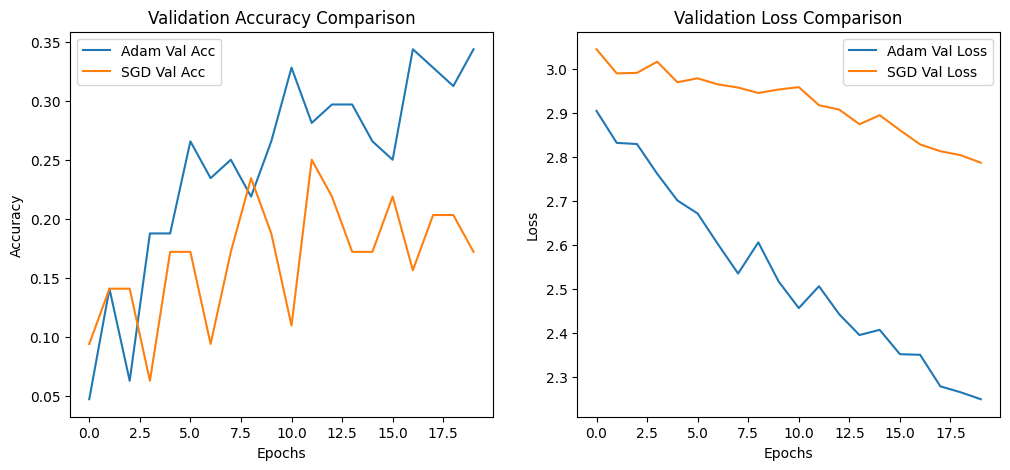

In [21]:
# Compare Results
if 'history_adam' in locals() and 'history_sgd' in locals():
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history_adam.history['val_accuracy'], label='Adam Val Acc')
    plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Acc')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
    plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

## 5. Feature Map Visualization
Visualizing the feature maps of the first convolutional layer to understand what features the model is learning (e.g., edges, textures).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


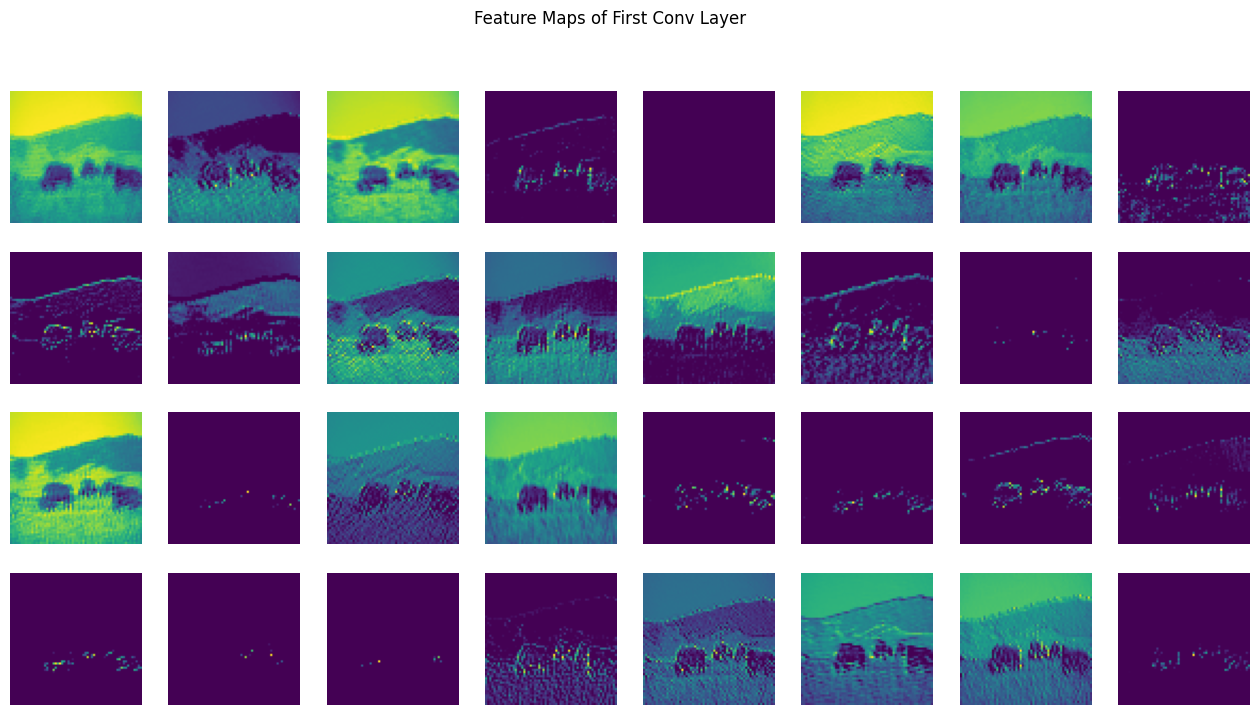

In [22]:
if 'model_adam' in locals() and 'X_test' in locals():
    # Create a model that returns the output of the first Conv layer
    first_layer_model = Model(inputs=model_adam.inputs, outputs=model_adam.layers[0].output)

    # Get feature maps for a sample image
    sample_img = X_test[0].reshape(1, 64, 64, 3)
    feature_maps = first_layer_model.predict(sample_img)

    # Plot feature maps
    plt.figure(figsize=(16, 8))
    num_maps = feature_maps.shape[-1]

    for i in range(min(num_maps, 32)):  # Plot first 32 maps
        plt.subplot(4, 8, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle("Feature Maps of First Conv Layer")
    plt.show()